In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
with open('../results/baseline_results.json') as f:
    baseline = json.load(f)

with open('../results/transformer_results.json') as f:
    transformers = json.load(f)

In [10]:
rows = []

# baseline models
for name, res in baseline.items():
    rows.append({
        'Model': name,
        'Accuracy': res['accuracy'],
        'F1 (Macro)': res['f1_macro']
    })

# transformer models
for name, res in transformers.items():
    
    # Structure is [logits(models predicted output), labels(true labels), metrics_dict(what we need: acc, f1)]
    # The metrics dict is always the last element
    if not isinstance(res, list) or len(res) == 0:
        print(f"Skipping {name} — unexpected format")
        continue
    
    metrics = res[-1]  # Last element is always the metrics dict [accuracy, f1 score] and only that is imp
    
    if not isinstance(metrics, dict):
        print(f"Skipping {name} — last element is not a dict: {type(metrics)}")
        continue

    rows.append({
        'Model': name,
        'Accuracy':   round(metrics.get('test_accuracy', 0), 4),
        'F1 (Macro)': round(metrics.get('test_f1_macro', 0), 4)
    })
    
results_df = pd.DataFrame(rows).sort_values(
    'F1 (Macro)', ascending=False
)

results_df.to_csv('../results/final_comparison.csv', index=False)

print(results_df.to_string(index=False))

      Model  Accuracy  F1 (Macro)
      mBERT    0.8617      0.8000
  TF-IDF+LR    0.8647      0.7975
 TF-IDF+SVM    0.8609      0.7945
XLM-RoBERTa    0.8515      0.7820
      MuRIL    0.8527      0.7808
      VADER    0.6333      0.5331


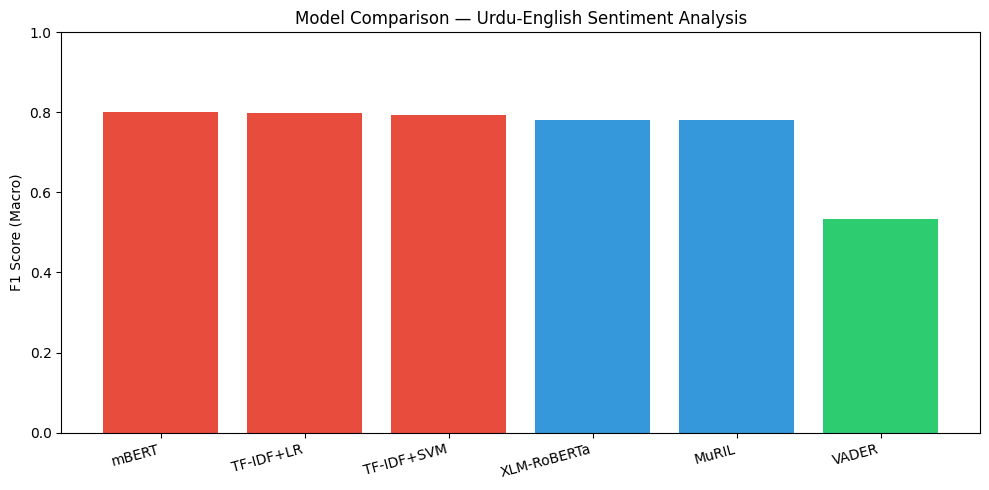

In [11]:
plt.figure(figsize=(10, 5))

x = range(len(results_df))

plt.bar(
    x,
    results_df['F1 (Macro)'],
    color=['#e74c3c','#e74c3c','#e74c3c',
           '#3498db','#3498db','#2ecc71']
)

plt.xticks(x, results_df['Model'], rotation=15, ha='right')
plt.ylabel('F1 Score (Macro)')
plt.title('Model Comparison — Urdu-English Sentiment Analysis')
plt.ylim(0, 1.0)

plt.tight_layout()
plt.savefig('../results/model_comparison_chart.png', dpi=150)
plt.show()